Economic Dataset:


,Year,Inflation,GDP_Growth,Exchange_Rate,Sensex
0,1978,7.745071,6.274895,8.592241,50.0
1,1979,7.300780,4.844194,10.160408,50.0
2,1980,8.973198,6.764376,11.286823,50.0
3,1981,10.750747,6.439304,12.445719,50.0
4,1982,8.537134,6.435931,11.722450,50.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           48 non-null     int64  
 1   Inflation      48 non-null     float64
 2   GDP_Growth     48 non-null     float64
 3   Exchange_Rate  48 non-null     float64
 4   Sensex         48 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.0 KB

Descriptive Statistics:


,Year,Inflation,GDP_Growth,Exchange_Rate,Sensex
count,48.00,48.000000,48.000000,48.000000,48.000000
mean,2001.50,7.142569,5.993832,46.460837,52.791513
std,14.00,2.560740,1.676748,22.947569,10.103699
min,1978.00,2.396096,3.000000,8.592241,50.000000
25%,1989.75,4.715968,4.640007,27.891170,50.000000
50%,2001.50,7.442887,6.200801,47.161695,50.000000
75%,2013.25,9.138565,7.471798,65.009975,50.000000
max,2025.00,11.927146,8.752764,85.369268,110.276786


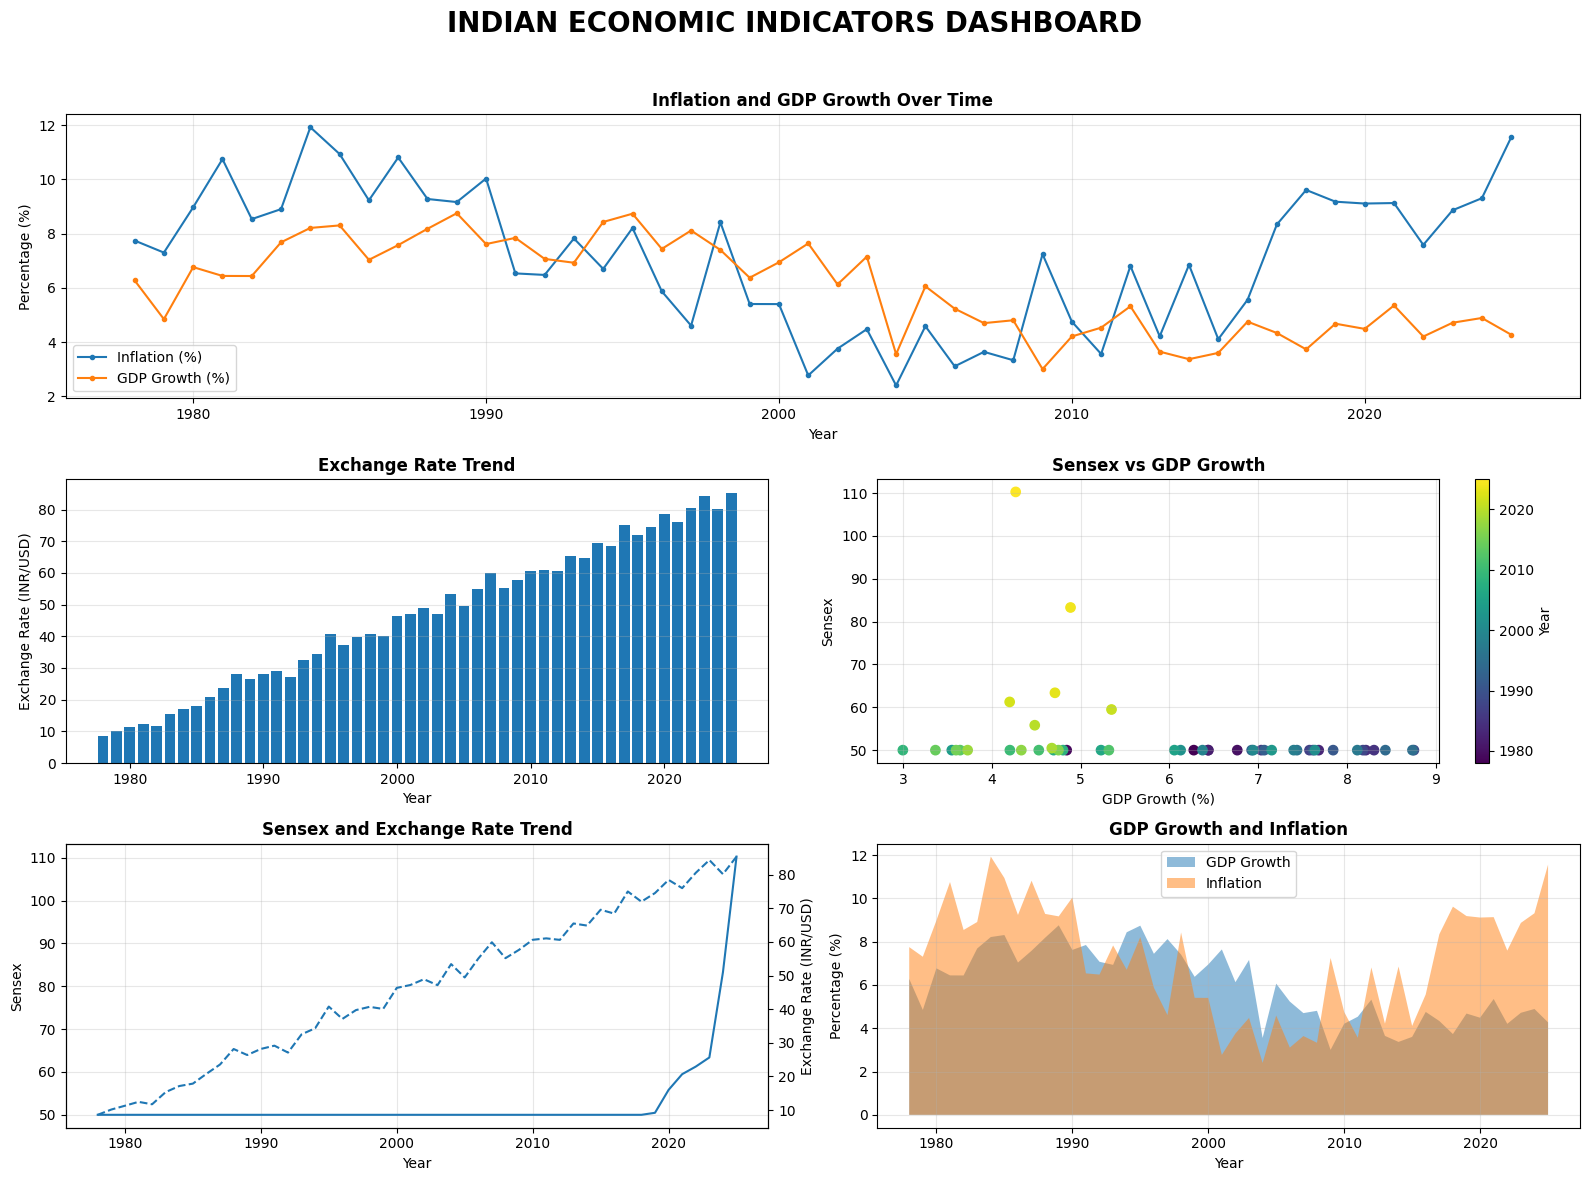

In [1]:
# ============================================================
# ECONOMIC DATA ANALYTICS DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ============================================================
# 1. CREATE SAMPLE ECONOMIC DATA
# ============================================================

years = np.arange(1978, 2026)

n = len(years)

# Inflation rate (%)
inflation = np.clip(
    7 + 3 * np.sin(np.linspace(0, 8, n))
    + np.random.normal(0, 1.5, n),
    2,
    14
)

# GDP Growth (%)
gdp_growth = np.clip(
    6 + 2 * np.sin(np.linspace(0, 6, n))
    + np.random.normal(0, 0.8, n),
    3,
    10
)

# Exchange rate INR/USD
exchange_rate = np.linspace(8, 85, n) + np.random.normal(0, 2, n)
exchange_rate = np.maximum(exchange_rate, 5)

# Sensex
sensex = (
    100
    * np.exp(np.linspace(0, 6, n))
    / np.exp(6)
)

# Add realistic variation
sensex = sensex * (
    1 + np.random.normal(0, 0.12, n)
)

# Keep Sensex positive
sensex = np.maximum(sensex, 50)


# Create DataFrame
df = pd.DataFrame({
    'Year': years,
    'Inflation': inflation,
    'GDP_Growth': gdp_growth,
    'Exchange_Rate': exchange_rate,
    'Sensex': sensex
})


# ============================================================
# 2. DISPLAY DATA
# ============================================================

print("Economic Dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())


# ============================================================
# 3. CREATE DASHBOARD
# ============================================================

fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'INDIAN ECONOMIC INDICATORS DASHBOARD',
    fontsize=20,
    fontweight='bold'
)


# ============================================================
# 4. INFLATION + GDP GROWTH
# ============================================================

ax1 = plt.subplot2grid(
    (3, 2),
    (0, 0),
    colspan=2
)

ax1.plot(
    df['Year'],
    df['Inflation'],
    marker='o',
    markersize=3,
    label='Inflation (%)'
)

ax1.plot(
    df['Year'],
    df['GDP_Growth'],
    marker='o',
    markersize=3,
    label='GDP Growth (%)'
)

ax1.set_title(
    'Inflation and GDP Growth Over Time',
    fontweight='bold'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Percentage (%)')

ax1.legend()
ax1.grid(alpha=0.3)


# ============================================================
# 5. EXCHANGE RATE
# ============================================================

ax2 = plt.subplot2grid(
    (3, 2),
    (1, 0)
)

ax2.bar(
    df['Year'],
    df['Exchange_Rate'],
    width=0.8
)

ax2.set_title(
    'Exchange Rate Trend',
    fontweight='bold'
)

ax2.set_xlabel('Year')
ax2.set_ylabel('Exchange Rate (INR/USD)')

ax2.grid(
    axis='y',
    alpha=0.3
)


# ============================================================
# 6. SENSEX VS GDP GROWTH
# ============================================================

ax3 = plt.subplot2grid(
    (3, 2),
    (1, 1)
)

scatter = ax3.scatter(
    df['GDP_Growth'],
    df['Sensex'],
    c=df['Year'],
    cmap='viridis',
    s=45
)

ax3.set_title(
    'Sensex vs GDP Growth',
    fontweight='bold'
)

ax3.set_xlabel('GDP Growth (%)')
ax3.set_ylabel('Sensex')

plt.colorbar(
    scatter,
    ax=ax3,
    label='Year'
)

ax3.grid(alpha=0.3)


# ============================================================
# 7. SENSEX + EXCHANGE RATE TREND
# ============================================================

ax4 = plt.subplot2grid(
    (3, 2),
    (2, 0)
)

# Sensex
ax4.plot(
    df['Year'],
    df['Sensex'],
    label='Sensex'
)

ax4.set_xlabel('Year')
ax4.set_ylabel('Sensex')

# Second Y-axis
ax4_right = ax4.twinx()

ax4_right.plot(
    df['Year'],
    df['Exchange_Rate'],
    linestyle='--',
    label='Exchange Rate'
)

ax4_right.set_ylabel(
    'Exchange Rate (INR/USD)'
)

ax4.set_title(
    'Sensex and Exchange Rate Trend',
    fontweight='bold'
)

ax4.grid(alpha=0.3)


# ============================================================
# 8. GDP GROWTH + INFLATION AREA CHART
# ============================================================

ax5 = plt.subplot2grid(
    (3, 2),
    (2, 1)
)

ax5.fill_between(
    df['Year'],
    df['GDP_Growth'],
    alpha=0.5,
    label='GDP Growth'
)

ax5.fill_between(
    df['Year'],
    df['Inflation'],
    alpha=0.5,
    label='Inflation'
)

ax5.set_title(
    'GDP Growth and Inflation',
    fontweight='bold'
)

ax5.set_xlabel('Year')
ax5.set_ylabel('Percentage (%)')

ax5.legend()

ax5.grid(alpha=0.3)


# ============================================================
# 9. FINAL DASHBOARD FORMATTING
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()